<a href="https://colab.research.google.com/github/ajzal4you/Master-Project-/blob/main/Classification_Brain_Tumour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision matplotlib
!pip install torchcam # for Grad-CAM

In [ ]:
# Upload your kaggle.json
from google.colab import files
files.upload()  # Upload kaggle.json here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ajufaizal","key":"e4898331bf66276cef66552c7d1b5643"}'}

In [ ]:
# Set up Kaggle credentials
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -o brain-tumor-mri-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: Training/glioma/Tr-gl_0712.jpg  
  inflating: Training/glioma/Tr-gl_0713.jpg  
  inflating: Training/glioma/Tr-gl_0714.jpg  
  inflating: Training/glioma/Tr-gl_0715.jpg  
  inflating: Training/glioma/Tr-gl_0716.jpg  
  inflating: Training/glioma/Tr-gl_0717.jpg  
  inflating: Training/glioma/Tr-gl_0718.jpg  
  inflating: Training/glioma/Tr-gl_0719.jpg  
  inflating: Training/glioma/Tr-gl_0720.jpg  
  inflating: Training/glioma/Tr-gl_0721.jpg  
  inflating: Training/glioma/Tr-gl_0722.jpg  
  inflating: Training/glioma/Tr-gl_0723.jpg  
  inflating: Training/glioma/Tr-gl_0724.jpg  
  inflating: Training/glioma/Tr-gl_0725.jpg  
  inflating: Training/glioma/Tr-gl_0726.jpg  
  inflating: Training/glioma/Tr-gl_0727.jpg  
  inflating: Training/glioma/Tr-gl_0728.jpg  
  inflating: Training/glioma/Tr-gl_0729.jpg  
  inflating: Training/glioma/Tr-gl_0730.jpg  
  inflating: Training/glioma/Tr-gl_0731.jpg  
  inflating: Training/glioma/

In [ ]:
import os
import torch
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim # Define loss and optimizer
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
import numpy as np
import nibabel as nib
import PIL.Image as Image
import matplotlib.pyplot as plt

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from torch.utils.data import random_split
from torch.utils.data import DataLoader
from torch.utils.data import Dataset, DataLoader
from torchcam.methods import GradCAM
from torchcam.utils import overlay_mask
from google.colab import drive
from google.colab import files
from PIL import Image
from torchvision.transforms.functional import to_pil_image
from torchvision import transforms
from torchvision import datasets, transforms

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # To Set Device

In [ ]:
# STEP 3: Set transforms
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [ ]:
#Define Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [ ]:
# Load dataset (make sure folder name is correct)
dataset = datasets.ImageFolder("Training", transform=transform)

In [ ]:
# Train/Val split
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print(f"✅ Classes: {dataset.classes}")

✅ Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


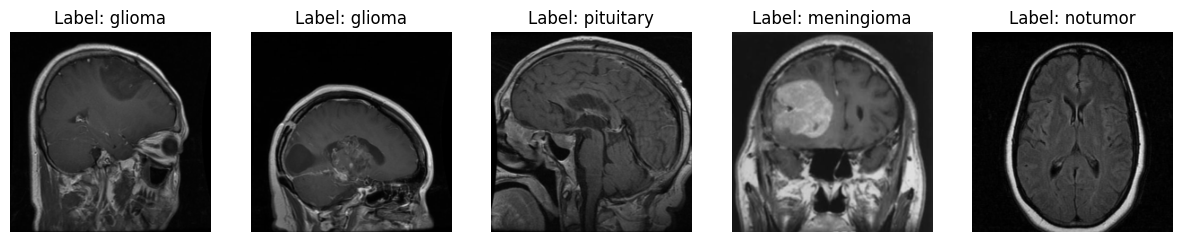

In [ ]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(5):
    img = images[i].permute(1, 2, 0) * 0.5 + 0.5
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {dataset.classes[labels[i]]}")
    axes[i].axis('off')
plt.show()

In [ ]:
# Toggle between CNN or ResNet18
use_resnet = True  # Set False to use custom CNN

if use_resnet:
    resnet = models.resnet18(pretrained=True)
    for param in resnet.parameters():
        param.requires_grad = False  # Freeze all layers
    resnet.fc = nn.Linear(resnet.fc.in_features, len(dataset.classes))
    model = resnet
else:
    class BrainTumorCNN(nn.Module):
        def __init__(self, num_classes):
            super(BrainTumorCNN, self).__init__()
            self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
            self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
            self.pool = nn.MaxPool2d(2, 2)
            self.fc1 = nn.Linear(32 * 56 * 56, 128)
            self.fc2 = nn.Linear(128, num_classes)

        def forward(self, x):
            x = self.pool(F.relu(self.conv1(x)))
            x = self.pool(F.relu(self.conv2(x)))
            x = x.view(-1, 32 * 56 * 56)
            x = F.relu(self.fc1(x))
            return self.fc2(x)

    model = BrainTumorCNN(num_classes=len(dataset.classes))

model = model.to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 160MB/s]


In [ ]:
# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Training Loop
epochs = 5
train_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))

    # Validation Accuracy
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_accuracies.append(val_acc)
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_losses[-1]:.4f} | Val Accuracy: {val_acc:.2f}%")

Epoch [1/5] | Train Loss: 0.6801 | Val Accuracy: 82.15%
Epoch [2/5] | Train Loss: 0.4373 | Val Accuracy: 85.56%
Epoch [3/5] | Train Loss: 0.3847 | Val Accuracy: 86.70%
Epoch [4/5] | Train Loss: 0.3512 | Val Accuracy: 88.71%


In [ ]:
# Plotting Train Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, marker='o', color='blue')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)

# Plotting Validation Accuracy
plt.subplot(1, 2, 2)
plt.plot(val_accuracies, marker='o', color='green')
plt.title("Validation Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#Save model
torch.save(model.state_dict(), "brain_tumor_model.pth")
print("🧠 Model saved as 'brain_tumor_model.pth'")

In [ ]:
#  Confusion Matrix & Classification Report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=dataset.classes)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(all_labels, all_preds, target_names=dataset.classes))


In [ ]:
# Initialize GradCAM
cam_extractor = GradCAM(model, target_layer="layer4" if use_resnet else "conv2")

In [ ]:
# Function to visualize one image
def visualize_gradcam(image_tensor, label):
    model.train() # Set model to training mode to enable gradients
    image_tensor = image_tensor.unsqueeze(0).to(device)  # Add batch dim

    # Enable gradients for the model parameters
    for param in model.parameters():
        param.requires_grad = True

    output = model(image_tensor)

    # Get predicted class
    pred_class = output.argmax(dim=1).item()

    # Generate CAM
    activation_map = cam_extractor(pred_class, output)[0].cpu()

    # Convert to PIL for visualization
    orig_img = image_tensor.squeeze().cpu()
    orig_img = orig_img * 0.5 + 0.5  # Unnormalize
    orig_img = to_pil_image(orig_img)

    heatmap = overlay_mask(orig_img, to_pil_image(activation_map, mode='F'), alpha=0.5)
    plt.imshow(heatmap)
    plt.title(f"Predicted: {dataset.classes[pred_class]} | True: {dataset.classes[label]}")
    plt.axis('off')
    plt.show()

    # Set the model back to evaluation mode and freeze layers
    model.eval()
    for param in model.parameters():
        param.requires_grad = False

In [ ]:
# ✅ Run Grad-CAM on 5 validation samples
count = 0
for inputs, labels in val_loader:
    for img, label in zip(inputs, labels):
        visualize_gradcam(img, label)
        count += 1
        if count >= 5:
            break
    if count >= 5:
        break

In [ ]:

# Root project folder
root = "/content/brain_classification"

# Subfolders
folders = [
    "data",             # for raw or processed MRI data
    "models",           # for saved .pth model files
    "outputs",          # for Grad-CAM images or plots
    "notebooks",        # optional: to save your final .ipynb here
    "utils"             # optional: utility/helper functions
]

# Create folders
for folder in folders:
    path = os.path.join(root, folder)
    os.makedirs(path, exist_ok=True)

print(" Folder structure created under /content/brain_classification/")
